In [378]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from lib.readwav import readwav
import ipywidgets as widgets
import json
import emcee
from scipy.special import logsumexp


In [379]:
%matplotlib widget
plt.close('all')

In [380]:
piano_dir = "dati_piano"
piano_files = [f for f in os.listdir(piano_dir) if f.endswith('.wav')]
piano_files.sort()  # Sort files to ensure correct order

print("Available piano files:")
for f in piano_files:
    print(f" - {f}")

Available piano files:
 - Piano scala MI - lento.wav
 - Piano scala MI - medio.wav
 - Piano scala MI - veloce staccato.wav
 - Piano scala Mi - veloe legato.wav


In [381]:
waveform_dict = {}
for f in piano_files:
    filepath = os.path.join(piano_dir, f)
    fs, data = readwav(filepath)
    waveform_dict[f] = (fs, data)

print("\nLoaded waveforms:")
for f in piano_files:
    fs, data = waveform_dict[f]
    print(f" - {f}: fs={fs}, length={len(data)} samples")


Loaded waveforms:
 - Piano scala MI - lento.wav: fs=44100, length=1113980 samples
 - Piano scala MI - medio.wav: fs=44100, length=786300 samples
 - Piano scala MI - veloce staccato.wav: fs=44100, length=458620 samples
 - Piano scala Mi - veloe legato.wav: fs=44100, length=393084 samples


In [382]:
def moving_rms(x, window_size):
    """Calculate the moving RMS of a signal."""
    return np.sqrt(np.convolve(x**2, np.ones(window_size)/window_size, mode='valid'))

def secs_to_samples(secs, fs):
    """Convert seconds to samples."""
    return secs * fs

def samples_to_secs(samples, fs):
    """Convert samples to seconds."""
    return samples / fs

In [383]:
def compute_spectral_flux(segment, frame_size, hop_size):
    """Compute the spectral flux of a signal segment."""
    # Compute the magnitude spectrum
    window = np.hanning(frame_size)
    frames = sp.signal.stft(segment, nperseg=frame_size, noverlap=frame_size - hop_size, window=window)[2]
    magnitude_spectrum = np.abs(frames)
    
    # Compute spectral flux
    spectral_flux = np.sqrt(np.sum(np.diff(magnitude_spectrum, axis=1)**2, axis=0))

    inds = np.arange(len(spectral_flux)) * hop_size

    return inds, spectral_flux

def detect_onsets(signal, fs):
    """Detect onsets from the signal."""

    frame_size = 1024
    hop_size = 512

    inds, spectral_flux = compute_spectral_flux(signal, frame_size, hop_size)

    flux_peaks, _ = sp.signal.find_peaks(spectral_flux, prominence=1000, distance=10)

    return inds[flux_peaks]

def segment_signal(signal, fs, onsets):
    """Segment the signal based on detected onsets."""
    segments = []
    for i in range(len(onsets) - 1):
        start_time = onsets[i]
        end_time = onsets[i + 1]
        segment = signal[int(start_time):int(end_time)]
        segments.append(segment)
    return segments

Dropdown(description='Select file:', options=('Piano scala MI - lento.wav', 'Piano scala MI - medio.wav', 'Pia…

IntSlider(value=1024, continuous_update=False, description='RMS Window Size:', max=8192, min=256, step=256)

IntSlider(value=10, continuous_update=False, description='Convolve Window:', max=1000, min=1)

/tmp/ipykernel_10559/3097506151.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.convolve(x**2, np.ones(window_size)/window_size, mode='valid'))


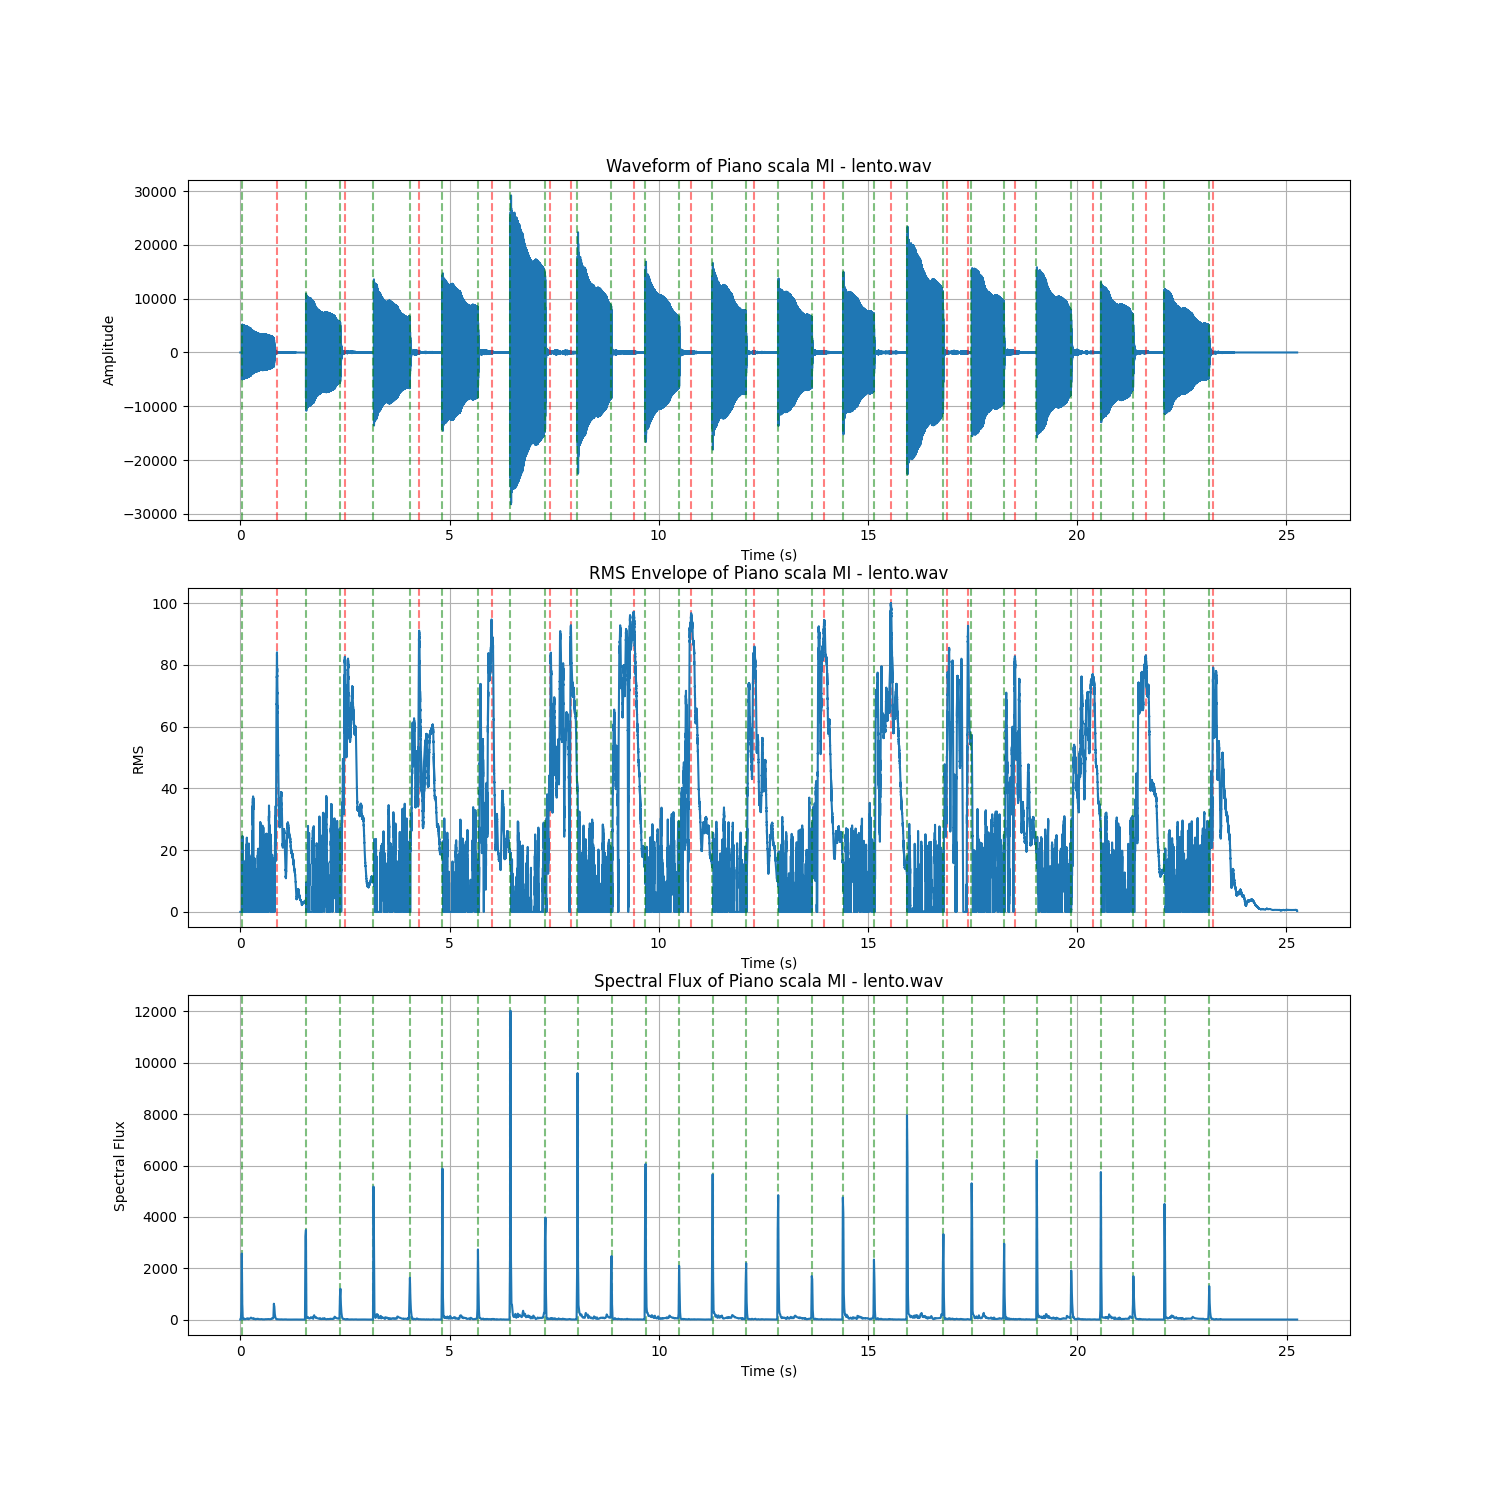

In [384]:
file_select = widgets.Dropdown(
    options=piano_files,
    description='Select file:',
    disabled=False,
)

window_size_slider = widgets.IntSlider(
    value=1024,
    min=256,
    max=8192,
    step=256,
    description='RMS Window Size:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
)

convolve_window_slider = widgets.IntSlider(
    value=10,
    min=1,
    max=1000,
    step=1,
    description='Convolve Window:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
)

def on_file_change(change):
    selected_file = change['new']
    fs, data = waveform_dict[selected_file]

    ch1 = data[:, 0]
    ch2 = data[:, 1]

    waveform_ax[0].clear()
    waveform_ax[0].plot(np.arange(len(data)) / fs, ch1, label='Channel 1')
    #waveform_ax[0].plot(np.arange(len(data)) / fs, ch2, label='Channel 2')
    waveform_ax[0].set_title(f"Waveform of {selected_file}")
    waveform_ax[0].set_xlabel("Time (s)")
    waveform_ax[0].set_ylabel("Amplitude")
    waveform_ax[0].grid()

    waveform_ax[1].clear()

    rms_ch1 = moving_rms(ch1, window_size=window_size_slider.value)
    rms_ch1 = np.concatenate((np.zeros(window_size_slider.value-1), rms_ch1))  # Pad to match original length

    # remove infs and nans
    rms_ch1 = np.nan_to_num(rms_ch1, nan=0.0, posinf=0.0, neginf=0.0)

    # convolve to smooth the RMS envelope
    rms_ch1 = np.convolve(rms_ch1, np.ones(convolve_window_slider.value)/convolve_window_slider.value, mode='same')

    norm_rms_ch1 = rms_ch1 / np.max(rms_ch1) * 100  # Normalize to percentage

    # find peaks in the RMS envelope
    peaks, _ = sp.signal.find_peaks(norm_rms_ch1, height=40, distance=secs_to_samples(0.5, fs))

    for peak in peaks:
        waveform_ax[1].axvline(x=peak/fs, color='r', linestyle='--', alpha=0.5)
        waveform_ax[0].axvline(x=peak/fs, color='r', linestyle='--', alpha=0.5)

    time_rms = np.arange(len(rms_ch1)) / fs

    waveform_ax[1].plot(time_rms, norm_rms_ch1, label='RMS Channel 1')
    #rms_ch2 = moving_rms(ch2, window_size=window_size_slider.value)
    #waveform_ax[1].plot(time_rms, rms_ch2, label='RMS Channel 2')
    waveform_ax[1].set_title(f"RMS Envelope of {selected_file}")
    waveform_ax[1].set_xlabel("Time (s)")
    waveform_ax[1].set_ylabel("RMS")
    waveform_ax[1].grid()

    waveform_ax[2].clear()
    inds, spectral_flux = compute_spectral_flux(ch1, frame_size=1024, hop_size=512)

    time_flux = inds / fs

    flux_peaks, _ = sp.signal.find_peaks(spectral_flux, prominence=1000, distance=10)

    for peak in flux_peaks:
        waveform_ax[2].axvline(x=peak * (512 / fs), color='g', linestyle='--', alpha=0.5)
        waveform_ax[0].axvline(x=peak * (512 / fs), color='g', linestyle='--', alpha=0.5)
        waveform_ax[1].axvline(x=peak * (512 / fs), color='g', linestyle='--', alpha=0.5)

    waveform_ax[2].plot(time_flux, spectral_flux, label='Spectral Flux')
    waveform_ax[2].set_title(f"Spectral Flux of {selected_file}")
    waveform_ax[2].set_xlabel("Time (s)")
    waveform_ax[2].set_ylabel("Spectral Flux")
    waveform_ax[2].grid()

    waveform_fig.canvas.draw()

def update_plots(change):
    on_file_change({'new': file_select.value})

with plt.ioff():
    waveform_fig, waveform_ax = plt.subplots(figsize=(15, 15), nrows=3)

    waveform_ax[0].set_title("Waveform")
    waveform_ax[0].set_xlabel("Time (s)")
    waveform_ax[0].set_ylabel("Amplitude")
    waveform_ax[0].grid()

    waveform_ax[1].set_title("RMS Envelope")
    waveform_ax[1].set_xlabel("Time (s)")
    waveform_ax[1].set_ylabel("RMS")
    waveform_ax[1].grid()

    waveform_ax[2].set_title("Spectral Flux")
    waveform_ax[2].set_xlabel("Time (s)")
    waveform_ax[2].set_ylabel("Spectral Flux")
    waveform_ax[2].grid()


display(file_select, window_size_slider, convolve_window_slider)
file_select.observe(on_file_change, names='value')
window_size_slider.observe(update_plots, names='value')
convolve_window_slider.observe(update_plots, names='value')
on_file_change({'new': file_select.value})  # Initialize with the first file
plt.show()


In [385]:
filename = "Piano scala Mi - veloe legato.wav"

waveform = waveform_dict[filename][1]
fs = waveform_dict[filename][0]

ch1 = waveform[:, 0]
ch2 = waveform[:, 1]

frame_size = 1024
hop_size = 512

onsets = detect_onsets(ch1, fs)

print("Detected onsets (in seconds):", samples_to_secs(onsets, fs))

segments = segment_signal(ch1, fs, onsets)

Detected onsets (in seconds): [0.04643991 0.56888889 1.04489796 1.50929705 1.98530612 2.47292517
 2.93732426 3.41333333 3.86612245 4.34213152 4.80653061 5.25931973
 5.7353288  6.17650794 6.65251701 7.25623583]


In [386]:
#def detect_onsets(rms, fs, threshold=40, min_distance_secs=0.5, window_size=1024, smoothing=1):
#    """Detect onsets in an RMS envelope."""
#    # Smooth the RMS envelope
#    if smoothing > 1:
#        rms = np.convolve(rms, np.ones(smoothing)/smoothing, mode='same')
#
#    # Normalize RMS to percentage
#    norm_rms = rms / np.max(rms) * 100
#
#    # Find peaks in the RMS envelope
#    peaks, _ = sp.signal.find_peaks(norm_rms, height=threshold, distance=secs_to_samples(min_distance_secs, fs))
#
#    return peaks, norm_rms
#
#filename = "Piano scala MI - veloce staccato.wav"
#
#waveform = waveform_dict[filename][1]
#fs = waveform_dict[filename][0]
#
#ch1 = waveform[:, 0]
#ch2 = waveform[:, 1]
#
#rms_ch1 = moving_rms(ch1, window_size=window_size_slider.value)
#rms_ch1 = np.concatenate((np.zeros(window_size_slider.value-1), rms_ch1))  # Pad to match original length
#rms_ch1 = np.nan_to_num(rms_ch1, nan=0.0, posinf=0.0, neginf=0.0)  # Remove infs and nans
#
#peaks, norm_rms_ch1 = detect_onsets(rms_ch1, fs, threshold=40, min_distance_secs=0.5, window_size=2048, smoothing=100)
#
#print(f"Detected onsets at: {samples_to_secs(peaks, fs)} seconds")

In [387]:
## cut the waveform into segments based on detected onsets
#segments = []
#peaks_with0 = np.concatenate(([0], peaks))  # Add start of the waveform as boundaries
#for i in range(len(peaks_with0)-1):
#    start_sample = peaks_with0[i]
#    end_sample = peaks_with0[i+1]
#    segment = ch1[start_sample:end_sample]
#    segments.append(segment)
#
#

In [388]:
def compute_avg_spectrum(segment, fs):
    width = (len(segment) / fs) / 10  # Set width to 1/10th of the segment duration
    gaussian_window = sp.signal.windows.gaussian(int(width * fs), std = 0.2 * fs)
    freqs, avg_spectrum = sp.signal.welch(segment, fs = fs, window = gaussian_window, nperseg = len(gaussian_window))
    return freqs, avg_spectrum

def compute_avg_spectrum_nperiods(segment, fs, n_periods=10):

    peaks, _ = sp.signal.find_peaks(segment, height=np.max(segment)*0.5)

    peaks_diff = np.diff(peaks)
    if len(peaks_diff) == 0:
        return None, None  # Not enough peaks to compute periods
    
    period = np.median(peaks_diff)  # Estimate period as median distance between peaks
    segment_length = len(segment)
    n_samples_per_period = int(period)
    n_samples_to_use = n_samples_per_period * n_periods

    window = sp.signal.windows.gaussian(n_samples_to_use, std=0.2 * n_samples_to_use)

    freqs, avg_spectrum = sp.signal.welch(segment, fs=fs, window=window, nperseg=len(window))

    return freqs, avg_spectrum


# compute power spectrum for each segment
power_spectra = []
for segment in segments:
    freqs, psd = compute_avg_spectrum_nperiods(segment, fs, n_periods=20)
    power_spectra.append((freqs, psd))

In [389]:
def cleanup_segments(segments, fs, min_duration_secs=0.1, window_size=2048):
    """
    Cut each segment again, to remove small amplitude tails at the beginning and end of each segment.
    """
    for i in range(len(segments)):
        segment = segments[i]
        
        segment_peaks, _ = sp.signal.find_peaks(segment, height=np.max(segment)*0.1)

        if len(segment_peaks) == 0:
            segments[i] = None  # Mark for removal
            continue

        start_sample = segment_peaks[0]
        end_sample = segment_peaks[-1]

        segments[i] = segment[start_sample:end_sample]
    
    # Remove segments that are too short
    segments = [seg for seg in segments if seg is not None]
    return segments

In [390]:
segments = cleanup_segments(segments, fs, min_duration_secs=0.1, window_size=2048)

In [391]:
avg_amplitudes = np.array([np.mean(np.abs(seg)) for seg in segments])

avg_amplitude = np.mean(avg_amplitudes)

filtered_segments = [seg for seg in segments if np.mean(np.abs(seg)) > avg_amplitude * 0.5]


In [392]:
def find_peaks(segment_psd, freqs, prominence=5, height=0, distance=10):

    spectrum = np.log10(segment_psd)

    # remove infs and nans
    spectrum = np.nan_to_num(spectrum, nan=0.0, posinf=0.0, neginf=0.0)

    norm_spectrum = spectrum / np.max(spectrum) * 100  # Normalize to percentage

    peaks_params = {
        "prominence": prominence,
        "height": height,
        "distance": distance
    }

    peaks, _ = sp.signal.find_peaks(norm_spectrum, **peaks_params)


    return freqs[peaks]

In [393]:
spectrum_peaks = []
for i, (freqs, psd) in enumerate(power_spectra):
    
    spectrum_peaks.append(find_peaks(psd, freqs, prominence=20, height=0, distance=10))

    print(f"Segment {i+1}: Detected peaks at frequencies: {spectrum_peaks[-1]} Hz")

Segment 1: Detected peaks at frequencies: [ 329.10447761  658.20895522  987.31343284 2550.55970149] Hz
Segment 2: Detected peaks at frequencies: [ 370.58823529  741.17647059 1111.76470588 1482.35294118 1852.94117647
 2316.17647059 2686.76470588 3057.35294118 3427.94117647] Hz
Segment 3: Detected peaks at frequencies: [ 416.03773585  832.0754717  1248.11320755 1664.1509434  2080.18867925
 2496.22641509 3037.0754717  3453.11320755 3869.1509434 ] Hz
Segment 4: Detected peaks at frequencies: [ 441.   882.  1323.  1764.  1984.5 2205.  2646.  2910.6 3263.4 3704.4] Hz
Segment 5: Detected peaks at frequencies: [ 490.  980. 1470. 3479. 3969.] Hz
Segment 6: Detected peaks at frequencies: [ 551.25 1102.5  1653.75 4226.25] Hz
Segment 7: Detected peaks at frequencies: [ 621.12676056 1242.25352113 1863.38028169 2205.         4223.66197183
 4565.28169014] Hz
Segment 8: Detected peaks at frequencies: [ 197.46268657  658.20895522 1316.41791045 1974.62686567 4804.92537313] Hz
Segment 9: Detected peaks a

Dropdown(description='Select segment:', options=('Segment 1', 'Segment 2', 'Segment 3', 'Segment 4', 'Segment …

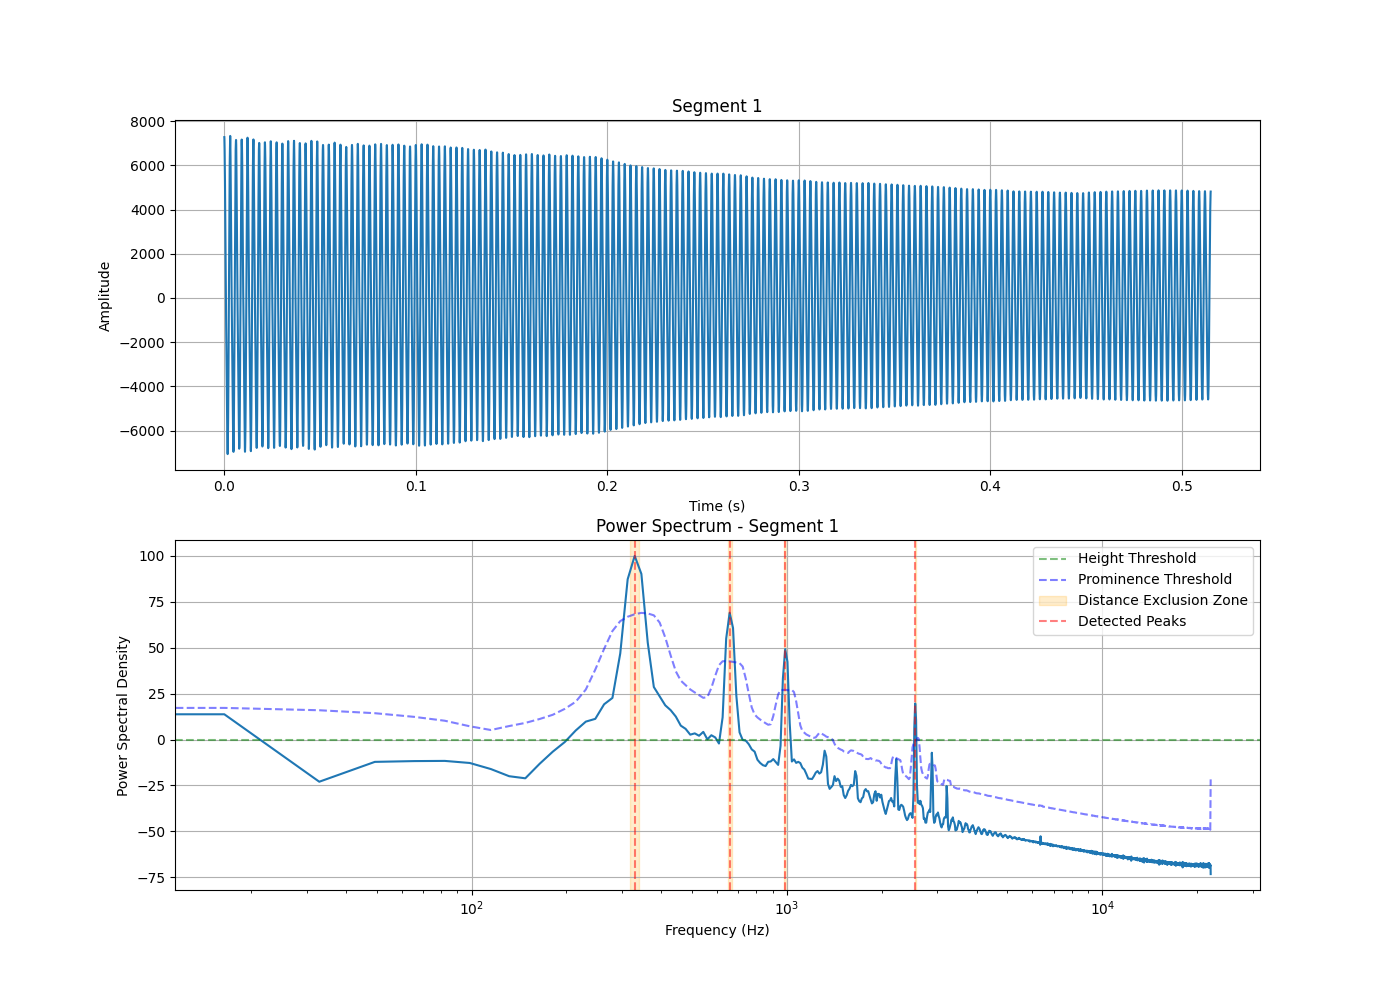

In [394]:
segment_select = widgets.Dropdown(
    options=[f"Segment {i+1}" for i in range(len(segments))],
    description='Select segment:',
    disabled=False,
)

with plt.ioff():
    segment_fig, segment_ax = plt.subplots(figsize=(14, 10), nrows=2)
    segment_ax[0].set_title("Selected Segment")
    segment_ax[0].set_xlabel("Time (s)")
    segment_ax[0].set_ylabel("Amplitude")
    segment_ax[0].grid()

    segment_ax[1].set_title("Power Spectrum")
    segment_ax[1].set_xlabel("Frequency (Hz)")
    segment_ax[1].set_ylabel("Power Spectral Density")
    segment_ax[1].grid()

def on_segment_change(change):
    selected_segment = change['new']
    index = int(selected_segment.split()[1]) - 1
    segment = segments[index]

    segment_ax[0].clear()
    segment_ax[0].plot(np.arange(len(segment)) / fs, segment)
    segment_ax[0].set_title(f"Segment {index+1}")
    segment_ax[0].set_xlabel("Time (s)")
    segment_ax[0].set_ylabel("Amplitude")
    segment_ax[0].grid()

    segment_psd = power_spectra[index][1]

    spectrum = segment_psd
    spectrum = np.log10(segment_psd)

    # remove infs and nans
    spectrum = np.nan_to_num(spectrum, nan=0.0, posinf=0.0, neginf=0.0)

    norm_spectrum = spectrum / np.max(spectrum) * 100  # Normalize to percentage

    segment_ax[1].clear()
    segment_ax[1].plot(power_spectra[index][0], norm_spectrum)
    segment_ax[1].set_title(f"Power Spectrum - Segment {index+1}")
    segment_ax[1].set_xlabel("Frequency (Hz)")
    segment_ax[1].set_ylabel("Power Spectral Density")
    segment_ax[1].set_xscale('log')
    #segment_ax[1].set_yscale('log')
    segment_ax[1].grid()

    peaks_params = {
        #"prominence": 100,
        "prominence": 20,
        "height": 0,
        "distance": 10
    }

    if "height" in peaks_params:
        segment_ax[1].axhline(y=peaks_params["height"], color='g', linestyle='--', alpha=0.5, label='Height Threshold')
    
    if "prominence" in peaks_params:
        y_moving_avg = sp.signal.convolve(norm_spectrum, np.ones(10)/10, mode='same')
        y_plus_prominence = y_moving_avg + peaks_params["prominence"]
        segment_ax[1].plot(power_spectra[index][0], y_plus_prominence, color='b', linestyle='--', alpha=0.5, label='Prominence Threshold')        
    
    peaks, _ = sp.signal.find_peaks(norm_spectrum, **peaks_params)

    if "distance" in peaks_params:
        for peak in peaks:
            x1 = power_spectra[index][0][peak] - peaks_params["distance"]
            x2 = power_spectra[index][0][peak] + peaks_params["distance"]
            segment_ax[1].axvspan(x1, x2, color='orange', alpha=0.2, label='Distance Exclusion Zone' if peak == peaks[0] else "")


    for peak in peaks:
        segment_ax[1].axvline(x=power_spectra[index][0][peak], color='r', linestyle='--', alpha=0.5, label='Detected Peaks' if peak == peaks[0] else "")
    
    segment_ax[1].legend()

    segment_fig.canvas.draw()

segment_select.observe(on_segment_change, names='value')
display(segment_select)
on_segment_change({'new': segment_select.value})  # Initialize with the first segment
plt.show()

In [395]:
from numpy.strings import index


def get_f0_first_peak(peak_freqs, freqs, spectrum):
    return peak_freqs[0] if len(peak_freqs) > 0 else None


def get_f0_from_gcd(peak_freqs):

    if len(peak_freqs) < 2:
        return None

    peak_freqs = np.sort(peak_freqs)[:6]

    reference_peak = peak_freqs[0]

    best_f0 = reference_peak
    best_score = float('inf')

    for n in range(1, 7):
        f0_candidate = reference_peak / n
        
        residuals = [np.abs(f / f0_candidate - round(f / f0_candidate)) for f in peak_freqs]
        
        avg_error = np.mean(residuals)

        if avg_error < 0.05:
            return f0_candidate

        if avg_error < best_score:
            best_score = avg_error
            best_f0 = f0_candidate
            
    return best_f0

def get_f0_gcd_mag_aware(peak_freqs, psd):

    f0_candidate = get_f0_from_gcd(peak_freqs)

    best_f0 = f0_candidate
    best_mag = psd[np.argmin(np.abs(freqs - f0_candidate))]

    for n in range(1, 20):

        f = f0_candidate * n

        if f > freqs[-1]:
            break

        idx = np.argmin(np.abs(freqs - f))
        mag = psd[idx]
        if mag > best_mag:
            best_mag = mag
            best_f0 = f0_candidate
    
    return best_f0

def get_f0_linear_regression(peak_freqs, peak_mags):

    if len(peak_freqs) < 2 or len(peak_mags) < 2:
        return None

    top_indices = np.argsort(peak_mags)[-6:]
    top_freqs = np.sort(peak_freqs[top_indices]) 

    rough_f0 = top_freqs[0]

    x = np.round(top_freqs / rough_f0)
    y = top_freqs

    valid = x > 0
    x = x[valid]
    y = y[valid]

    if len(x) < 2:
        return rough_f0

    A = np.vstack([x, np.ones(len(x))]).T
    m, c = np.linalg.lstsq(A, y, rcond=None)[0] 
    
    return m  

In [396]:
def get_limiti_prior(observed_freqs):

    f_min = np.min(observed_freqs) * 0.5
    f_max = np.min(observed_freqs) * 3

    log_sigma_min = np.log(0.1)
    log_sigma_max = np.log(100)

    log_uniform = -np.log(f_max - f_min)

    return f_min, f_max, log_sigma_min, log_sigma_max, log_uniform

def compute_P_n_log_magnitude_aware(peak_freqs, peak_mags, ns, alpha=0.6, eps=1e-8):

    ns = np.asarray(ns)
    peak_freqs = np.asarray(peak_freqs)
    peak_mags = np.asarray(peak_mags)
   
    f0_guess = float(peak_freqs[0])

    env = np.zeros_like(ns, dtype=float)
    for fk, mk in zip(peak_freqs, peak_mags):
        if fk <= 0 or mk <= 0:
            continue
        n_est = int(np.round(fk / f0_guess))
        if 1 <= n_est <= ns[-1]:
            env[n_est - 1] += mk

    weights = (env + eps) * np.exp(-alpha * (ns - 1).astype(float))
    weights = weights / np.sum(weights)

    return np.log(weights)

def get_f0_bayesian_map(peak_freqs, peak_mags):

    f_min, f_max, log_sigma_min, log_sigma_max, log_uniform = get_limiti_prior(peak_freqs)

    # Parametri delle armoniche
    ns = np.arange(1, 21)   # Consideriamo le prime 20 armoniche
    P_n_log = compute_P_n_log_magnitude_aware(peak_freqs, peak_mags, np.arange(1,21))
    U_log = log_uniform # Probabilità uniforme del rumore
    q_min = 0
    q_max = 1

    def log_prob(theta):

        f0, log_sigma, q = theta
        sigma = np.exp(log_sigma)

        if not (f_min < f0 < f_max and log_sigma_min < log_sigma < log_sigma_max and q_min < q < q_max):
            return -1e15

        total_log_likelihood = 0.0

        for fk in peak_freqs:

            log_gaussians = -0.5 * ((fk - ns * f0) / sigma)**2 - log_sigma - 0.5 * np.log(2 * np.pi)
            
            log_p_harmonics = logsumexp(log_gaussians + P_n_log)

            log_p_total = np.logaddexp(np.log(q) + log_p_harmonics, np.log(1 - q) + U_log)
            
            total_log_likelihood += log_p_total

        return total_log_likelihood

    f_start = float(peak_freqs[0])  

    sigma_start = np.log(0.1*f_start)  

    q_start = 0.8

    x0 = [f_start, sigma_start, q_start]

    res = sp.optimize.minimize(
        lambda t: -log_prob(t),
        x0=x0,
        method='L-BFGS-B',
        bounds=[
            (f_min, f_max),
            (log_sigma_min, log_sigma_max),
            (q_min, q_max)
        ],
        options={'maxiter': 300}
    )

    f0_map, log_sigma_map, q_map = res.x
    q_map = float(np.clip(q_map, q_min, q_max))
    print(f"MAP Singolo -> F0: {f0_map:.2f}Hz, Sigma: {np.exp(log_sigma_map):.5f}Hz, q: {q_map:.8f}")

    return f0_map, q_map

In [ ]:
def get_limiti_prior_new(observed_freqs):

    f_min = np.min(observed_freqs) * 0.5
    f_max = np.min(observed_freqs) * 1.5

    log_sigma_min = np.log(0.1)
    log_sigma_max = np.log(100)

    return f_min, f_max, log_sigma_min, log_sigma_max

def f0_bayes_prior(f0, sigma, q, f_min, f_max, log_sigma_min, log_sigma_max):
    """
    Computes the log-prior probability of the model parameters (f0, sigma, q) based on the defined prior distributions.
     - f0 is assumed to have a gaussian prior centered around the first observed peak frequency with a standard deviation of 20% of that frequency.
     - sigma is assumed to have a uniform prior in log-space between log_sigma_min and log_sigma_max.
     - q is assumed to have a uniform prior between 0 and 1.
     The function returns the sum of the log-priors for all parameters.
    """

    if not (f_min < f0 < f_max):
        return -np.inf  # Log-prior is very low if f0 is out of bounds

    if not (log_sigma_min < np.log(sigma) < log_sigma_max):
        return -np.inf  # Log-prior is very low if sigma is out of bounds

    if not (0 < q < 1):
        return -np.inf  # Log-prior is very low if q is out of bounds

    log_prior_f0 = -0.5 * ((f0 - f_min) / (0.2 * f_min))**2 - np.log(0.2 * f_min) - 0.5 * np.log(2 * np.pi)  # Gaussian prior
    log_prior_sigma = -np.log(log_sigma_max - log_sigma_min) - np.log(sigma)  # Uniform in log-space
    log_prior_q = 0  # Uniform between 0 and 1

    return log_prior_f0 + log_prior_sigma + log_prior_q


def f0_bayes_likelihood(f0, sigma, q, peak_freqs, peak_mags, f_min, f_max):
    """
    Compute the log-likelihood of the observed peaks given the model parameters.
    The model assumes peaks are either harmonics of the fundamental frequency (with probability q) or noise (with probability 1-q).
    For harmonics, the expected frequencies are n*f0 with a Gaussian spread defined by sigma. The likelihood is computed in log-space for numerical stability.
    The indices are considered latent variables and marginalized out by summing over all possible n values.
    For noise, we assume a uniform distribution over the frequency range of interest, which contributes a constant log-likelihood.
    """

    ns = np.arange(1, 21)   # Consideriamo le prime 20 armoniche
    P_n_log = compute_P_n_log_magnitude_aware(peak_freqs, peak_mags, ns)
    U_log = np.log(1 / (f_max - f_min))  # Probabilità uniforme del rumore

    total_log_likelihood = 0.0

    for fk in peak_freqs:

        log_gaussians = -0.5 * ((fk - ns * f0) / sigma)**2 - np.log(sigma) - 0.5 * np.log(2 * np.pi)
        
        log_p_harmonics = logsumexp(log_gaussians + P_n_log)

        log_p_total = np.logaddexp(np.log(q) + log_p_harmonics, np.log(1 - q) + U_log)
        
        total_log_likelihood += log_p_total

    return total_log_likelihood



def f0_bayes_posterior(f0, sigma, q, peak_freqs, peak_mags, f_min, f_max, log_sigma_min, log_sigma_max):
    """
    Computes the probability of the model parameters (f0, sigma, q) given the observed data (peak frequencies and magnitudes) using Bayes' theorem.
    """

    log_prior = f0_bayes_prior(f0, sigma, q, f_min, f_max, log_sigma_min, log_sigma_max)
    if log_prior == -np.inf:
        return -np.inf  # If the prior is zero, the posterior is zero

    log_likelihood = f0_bayes_likelihood(f0, sigma, q, peak_freqs, peak_mags, f_min, f_max)

    return log_prior + log_likelihood

def run_mcmc(peak_freqs, peak_mags, f_min, f_max, log_sigma_min, log_sigma_max, n_walkers=50, n_steps=500):

    def log_prob(theta):
        f0, log_sigma, q = theta
        sigma = np.exp(log_sigma)
        return f0_bayes_posterior(f0, sigma, q, peak_freqs, peak_mags, f_min, f_max, log_sigma_min, log_sigma_max)

    initial_f0 = float(peak_freqs[0])
    initial_log_sigma = np.log(0.1 * initial_f0)
    initial_q = 0.8

    initial_pos = []
    for _ in range(n_walkers):
        f0_sample = np.random.uniform(f_min, f_max)
        log_sigma_sample = np.random.uniform(log_sigma_min, log_sigma_max)
        q_sample = np.random.uniform(0, 1)
        initial_pos.append([f0_sample, log_sigma_sample, q_sample])

    sampler = emcee.EnsembleSampler(n_walkers, 3, log_prob)

    sampler.run_mcmc(initial_pos, n_steps, progress=True)

    samples = sampler.get_chain(discard=int(n_steps/2), flat=True)

    return samples
    


In [406]:
f0s_dict = {
    "first_peak" : [],
    "gcd" : [],
    "magnitude aware gcd" : [],
    "linear_regression" : [],
    "bayesian_map" : [],
    "bayes mcmc" : []
}

In [408]:
qs = []
qs_mcmcm = []

for freqs, psd in power_spectra:
    peak_freqs = find_peaks(psd, freqs, prominence=20, height=0, distance=10)
    peaks_mags = psd[np.searchsorted(freqs, peak_freqs)]


    f0s_dict["first_peak"].append(get_f0_first_peak(peak_freqs, freqs, psd))

    f0s_dict["gcd"].append(get_f0_from_gcd(peak_freqs))

    f0s_dict["magnitude aware gcd"].append(get_f0_gcd_mag_aware(peak_freqs, psd))

    f0s_dict["linear_regression"].append(get_f0_linear_regression(peak_freqs, peaks_mags))

    f0_map, q_map = get_f0_bayesian_map(peak_freqs, peaks_mags)
    f0s_dict["bayesian_map"].append(f0_map)
    qs.append(q_map)

    f_min, f_max, log_sigma_min, log_sigma_max = get_limiti_prior_new(peak_freqs)
    samples = run_mcmc(peak_freqs, peaks_mags, f_min, f_max, log_sigma_min, log_sigma_max, n_walkers=50, n_steps=500)
    f0s_dict["bayes mcmc"].append(np.median(samples[:, 0]))
    qs_mcmcm.append(np.median(samples[:, 2]))


MAP Singolo -> F0: 329.10Hz, Sigma: 0.10000Hz, q: 0.66870280


100%|██████████| 500/500 [00:09<00:00, 52.36it/s]


MAP Singolo -> F0: 370.59Hz, Sigma: 0.10000Hz, q: 0.23267987


100%|██████████| 500/500 [00:20<00:00, 24.62it/s]


MAP Singolo -> F0: 416.04Hz, Sigma: 0.10000Hz, q: 0.31973439


...

100%|██████████| 500/500 [00:12<00:00, 39.01it/s]


MAP Singolo -> F0: 364.34Hz, Sigma: 0.10350Hz, q: 0.06011757


100%|██████████| 500/500 [00:12<00:00, 39.69it/s]


MAP Singolo -> F0: 329.10Hz, Sigma: 0.10000Hz, q: 0.35667734


100%|██████████| 500/500 [00:14<00:00, 35.33it/s]


In [409]:
print("\nEstimated F0s for each segment:")
for i in range(len(power_spectra)):
    print(f"Segment {i+1}, number of peaks: {len(peak_freqs)}")
    print(f"  First Peak: {f0s_dict['first_peak'][i]:.2f} Hz")
    print(f"  GCD Method: {f0s_dict['gcd'][i]:.2f} Hz")
    print(f"  Magnitude-Aware GCD: {f0s_dict['magnitude aware gcd'][i]:.2f} Hz")
    print(f"  Linear Regression: {f0s_dict['linear_regression'][i]:.2f} Hz")
    print(f"  Bayesian MAP: {f0s_dict['bayesian_map'][i]:.2f} Hz, q: {qs[i]:.8f}")
    print(f"  Bayesian MCMC: {f0s_dict['bayes mcmc'][i]:.2f} Hz, q: {qs_mcmcm[i]:.8f}")


Estimated F0s for each segment:
Segment 1, number of peaks: 8
  First Peak: 329.10 Hz
  GCD Method: 82.28 Hz
  Magnitude-Aware GCD: 82.28 Hz
  Linear Regression: 316.34 Hz
  Bayesian MAP: 329.10 Hz, q: 0.66870280
  Bayesian MCMC: 329.09 Hz, q: 0.18713294
Segment 2, number of peaks: 8
  First Peak: 329.10 Hz
  GCD Method: 82.28 Hz
  Magnitude-Aware GCD: 82.28 Hz
  Linear Regression: 316.34 Hz
  Bayesian MAP: 329.10 Hz, q: 0.23267987
  Bayesian MCMC: 370.50 Hz, q: 0.09043657
Segment 3, number of peaks: 8
  First Peak: 370.59 Hz
  GCD Method: 370.59 Hz
  Magnitude-Aware GCD: 370.59 Hz
  Linear Regression: 383.82 Hz
  Bayesian MAP: 370.59 Hz, q: 0.31973439
  Bayesian MCMC: 415.91 Hz, q: 0.07762299
Segment 4, number of peaks: 8
  First Peak: 416.04 Hz
  GCD Method: 416.04 Hz
  Magnitude-Aware GCD: 416.04 Hz
  Linear Regression: 433.87 Hz
  Bayesian MAP: 416.04 Hz, q: 0.30434758
  Bayesian MCMC: 440.92 Hz, q: 0.07401855
Segment 5, number of peaks: 8
  First Peak: 441.00 Hz
  GCD Method: 220

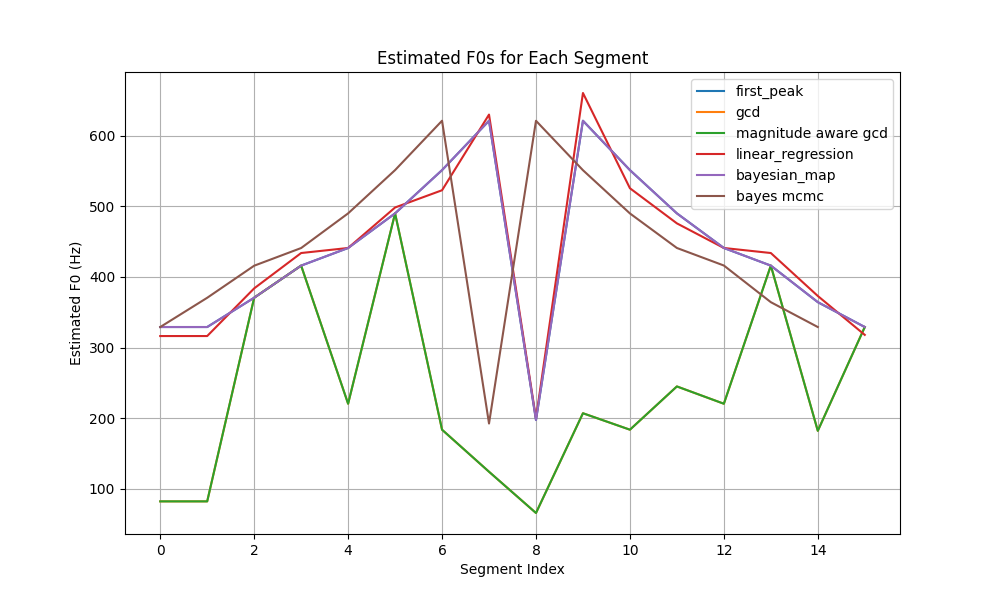

In [410]:
plt.figure(figsize=(10, 6))

for method, f0s in f0s_dict.items():
    plt.plot(f0s, label=method)

plt.title("Estimated F0s for Each Segment")
plt.xlabel("Segment Index")
plt.ylabel("Estimated F0 (Hz)")
plt.legend()
plt.grid()
plt.show()

In [411]:
note_freqs = {}
for octave in range(1, 7):  # 1..8
    for i, note in enumerate(["DO", "DO#", "RE", "RE#", "MI", "FA", "FA#", "SOL", "SOL#", "LA", "LA#", "SI"]):
        freq = 16.35 * (2 ** octave) * (2 ** (i / 12))
        note_freqs[f"{note}{octave}"] = freq

def find_closest_note(freq, note_freqs):
    closest_note = None
    min_diff = float('inf')
    for note, note_freq in note_freqs.items():
        diff = abs(freq - note_freq)
        if diff < min_diff:
            min_diff = diff
            closest_note = note
    return closest_note

print("Frequenze delle note:")
for note, freq in sorted(note_freqs.items()):
    print(f"  {note}: {freq:.2f} Hz")

Frequenze delle note:
  DO#1: 34.64 Hz
  DO#2: 69.29 Hz
  DO#3: 138.58 Hz
  DO#4: 277.16 Hz
  DO#5: 554.31 Hz
  DO#6: 1108.62 Hz
  DO1: 32.70 Hz
  DO2: 65.40 Hz
  DO3: 130.80 Hz
  DO4: 261.60 Hz
  DO5: 523.20 Hz
  DO6: 1046.40 Hz
  FA#1: 46.24 Hz
  FA#2: 92.49 Hz
  FA#3: 184.98 Hz
  FA#4: 369.96 Hz
  FA#5: 739.92 Hz
  FA#6: 1479.83 Hz
  FA1: 43.65 Hz
  FA2: 87.30 Hz
  FA3: 174.60 Hz
  FA4: 349.19 Hz
  FA5: 698.39 Hz
  FA6: 1396.78 Hz
  LA#1: 58.26 Hz
  LA#2: 116.53 Hz
  LA#3: 233.06 Hz
  LA#4: 466.12 Hz
  LA#5: 932.24 Hz
  LA#6: 1864.47 Hz
  LA1: 54.99 Hz
  LA2: 109.99 Hz
  LA3: 219.98 Hz
  LA4: 439.96 Hz
  LA5: 879.91 Hz
  LA6: 1759.83 Hz
  MI1: 41.20 Hz
  MI2: 82.40 Hz
  MI3: 164.80 Hz
  MI4: 329.60 Hz
  MI5: 659.19 Hz
  MI6: 1318.38 Hz
  RE#1: 38.89 Hz
  RE#2: 77.77 Hz
  RE#3: 155.55 Hz
  RE#4: 311.10 Hz
  RE#5: 622.19 Hz
  RE#6: 1244.39 Hz
  RE1: 36.70 Hz
  RE2: 73.41 Hz
  RE3: 146.82 Hz
  RE4: 293.64 Hz
  RE5: 587.27 Hz
  RE6: 1174.54 Hz
  SI1: 61.73 Hz
  SI2: 123.46 Hz
  SI3: 246

In [412]:
bayesian_f0s = f0s_dict["bayesian_map"]

print("\nEstimated notes for each segment (Bayesian MAP):")
for i, f0 in enumerate(bayesian_f0s):
    closest_note = find_closest_note(f0, note_freqs)
    print(f"Segment {i+1}: Estimated F0 = {f0:.2f} Hz, Closest Note = {closest_note}")



Estimated notes for each segment (Bayesian MAP):
Segment 1: Estimated F0 = 329.10 Hz, Closest Note = MI4
Segment 2: Estimated F0 = 329.10 Hz, Closest Note = MI4
Segment 3: Estimated F0 = 370.59 Hz, Closest Note = FA#4
Segment 4: Estimated F0 = 416.04 Hz, Closest Note = SOL#4
Segment 5: Estimated F0 = 441.00 Hz, Closest Note = LA4
Segment 6: Estimated F0 = 490.00 Hz, Closest Note = SI4
Segment 7: Estimated F0 = 551.25 Hz, Closest Note = DO#5
Segment 8: Estimated F0 = 621.13 Hz, Closest Note = RE#5
Segment 9: Estimated F0 = 197.53 Hz, Closest Note = SOL3
Segment 10: Estimated F0 = 621.13 Hz, Closest Note = RE#5
Segment 11: Estimated F0 = 551.25 Hz, Closest Note = DO#5
Segment 12: Estimated F0 = 490.00 Hz, Closest Note = SI4
Segment 13: Estimated F0 = 441.00 Hz, Closest Note = LA4
Segment 14: Estimated F0 = 416.04 Hz, Closest Note = SOL#4
Segment 15: Estimated F0 = 364.34 Hz, Closest Note = FA#4
Segment 16: Estimated F0 = 329.10 Hz, Closest Note = MI4


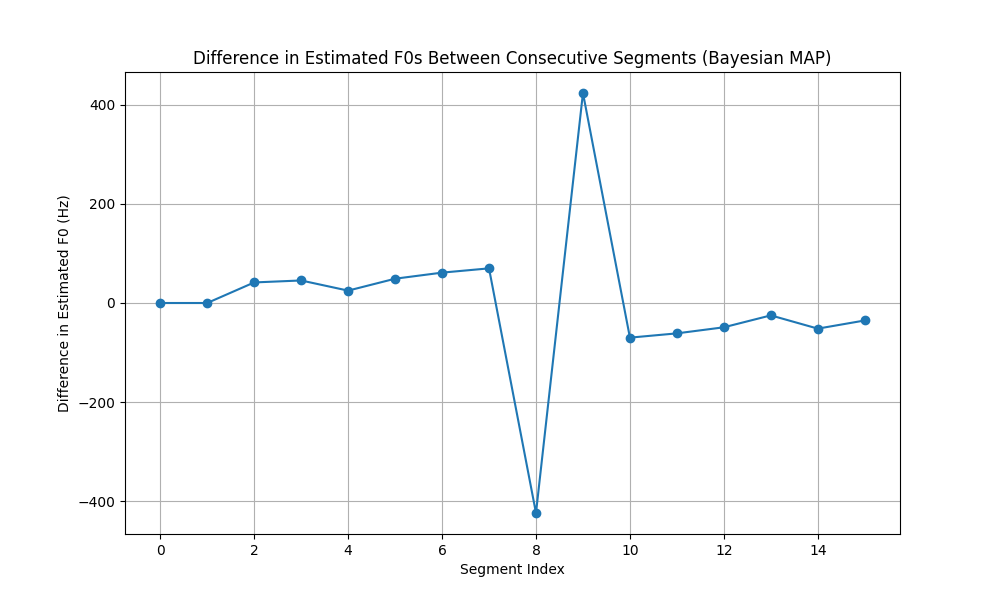

In [413]:
plt.figure(figsize=(10, 6))

f0s_diffs = np.diff(bayesian_f0s, prepend=bayesian_f0s[0])

plt.plot(f0s_diffs, marker='o')
plt.title("Difference in Estimated F0s Between Consecutive Segments (Bayesian MAP)")
plt.xlabel("Segment Index")
plt.ylabel("Difference in Estimated F0 (Hz)")
plt.grid()
plt.show()
